In [ ]:
#########################################################################
# # ! Moon Topographic-Gravitational-Potential Computation: PH vs SH
#########################################################################
# %% 
# # ! Setup
import numpy as np
import pyshtools as pysh
import pygmt
import xarray as xr
import time
from datetime import datetime
from gravity_forward_numba import *

In [ ]:
# # ! Start time
print("=" * 80)
print(f"Start time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

Start time: [2026-05-11 12:28:25]


In [ ]:
# # ! Constants
myG = 6.67430e-11
r_calc_km = 1748000.0 / 1.e3

In [ ]:
# # ! Shape of Moon
#### * Shape
lmax_shp = 359
clm_shp_moon = \
    pysh.SHCoeffs.from_file(f'input/Moon_shape_719.sh', 
                            lmax=lmax_shp, 
                            name='LOLA_shape (Moon)',
                            units='m', format='bshc')
r_itfc_km = clm_shp_moon.coeffs[0,0,0] / 1.e3
grd_shp_moon = clm_shp_moon.expand()
in_res = 90.0/(lmax_shp + 1)
grd_topo_moon = grd_shp_moon/ 1.e3 - r_itfc_km

In [ ]:
# # ! Load TGP data: SH vs PH
#### * SH
max_nmax = 6
nc_file_SH = f'output/moon_topo_gravity_Lshp{lmax_shp}_nmax{max_nmax}.nc'
data_SH = xr.open_dataset(nc_file_SH)
gn_SH = data_SH['gx'].data[::max_nmax, ::max_nmax]
ge_SH = data_SH['gy'].data[::max_nmax, ::max_nmax]
gd_SH = data_SH['gz'].data[::max_nmax, ::max_nmax]
#### * PH
out_res = 15.0/60.0 # degree
nc_file_PH = (f"output/moon_topo_gravity_in{int(in_res*60)}arcmin"
              f"_out{int(out_res*60)}arcmin.nc")
data_PH = xr.open_dataset(nc_file_PH)
gn_PH = data_PH['gN'].data
ge_PH = data_PH['gE'].data
gd_PH = data_PH['gD'].data
#### * Diff = PH - SH
d_gn = gn_PH - gn_SH
d_ge = ge_PH - ge_SH
d_gd = gd_PH - gd_SH
d_gn[[0, -1], :] = 0.0
d_ge[[0, -1], :] = 0.0
#### * Summary statistics
g_SH = {'N': gn_SH, 'E': ge_SH, 'D': gd_SH}
g_PH = {'N': gn_PH, 'E': ge_PH, 'D': gd_PH}
d_g  = {'N': d_gn,  'E': d_ge,  'D': d_gd}
print('-' * 80)
print('Gravity Vector components in mGal')
print(f"{'Type':4s} | {'Comp':4s} | {'min':>9s} | {'max':>9s} | {'mean':>9s} | {'std':>9s}")
print('-' * 80)
datasets = {'SH': g_SH, 'PH': g_PH, 'Diff': d_g}
for typ in ['SH', 'PH', 'Diff']:
    for comp in ['N', 'E', 'D']:
        data = datasets[typ][comp]
        print(f"{typ:4s} | {f'g{comp}':4s} | {data.min():9.4f} | {data.max():9.4f} | "
              f"{data.mean():9.4f} | {data.std():9.4f}")
    print('=' * 60)

--------------------------------------------------------------------------------
Gravity Vector components in mGal
Type | Comp |       min |       max |      mean |       std
--------------------------------------------------------------------------------
SH   | gN   | -488.8081 |  933.4514 |   10.3820 |  154.3514
SH   | gE   | -551.9960 |  606.5573 |    0.0197 |  150.2317
SH   | gD   | -721.9860 | 1188.2330 |  -35.0952 |  246.4136
PH   | gN   | -486.9639 |  926.2217 |   10.3856 |  154.2915
PH   | gE   | -548.6204 |  605.3110 |    0.0197 |  150.2471
PH   | gD   | -721.7818 | 1182.6341 |  -36.0165 |  246.2114
Diff | gN   |  -11.8385 |   12.4269 |    0.0033 |    0.8882
Diff | gE   |  -11.8478 |    9.9283 |   -0.0000 |    0.7193
Diff | gD   |  -20.4821 |   13.2734 |   -0.9213 |    1.1317


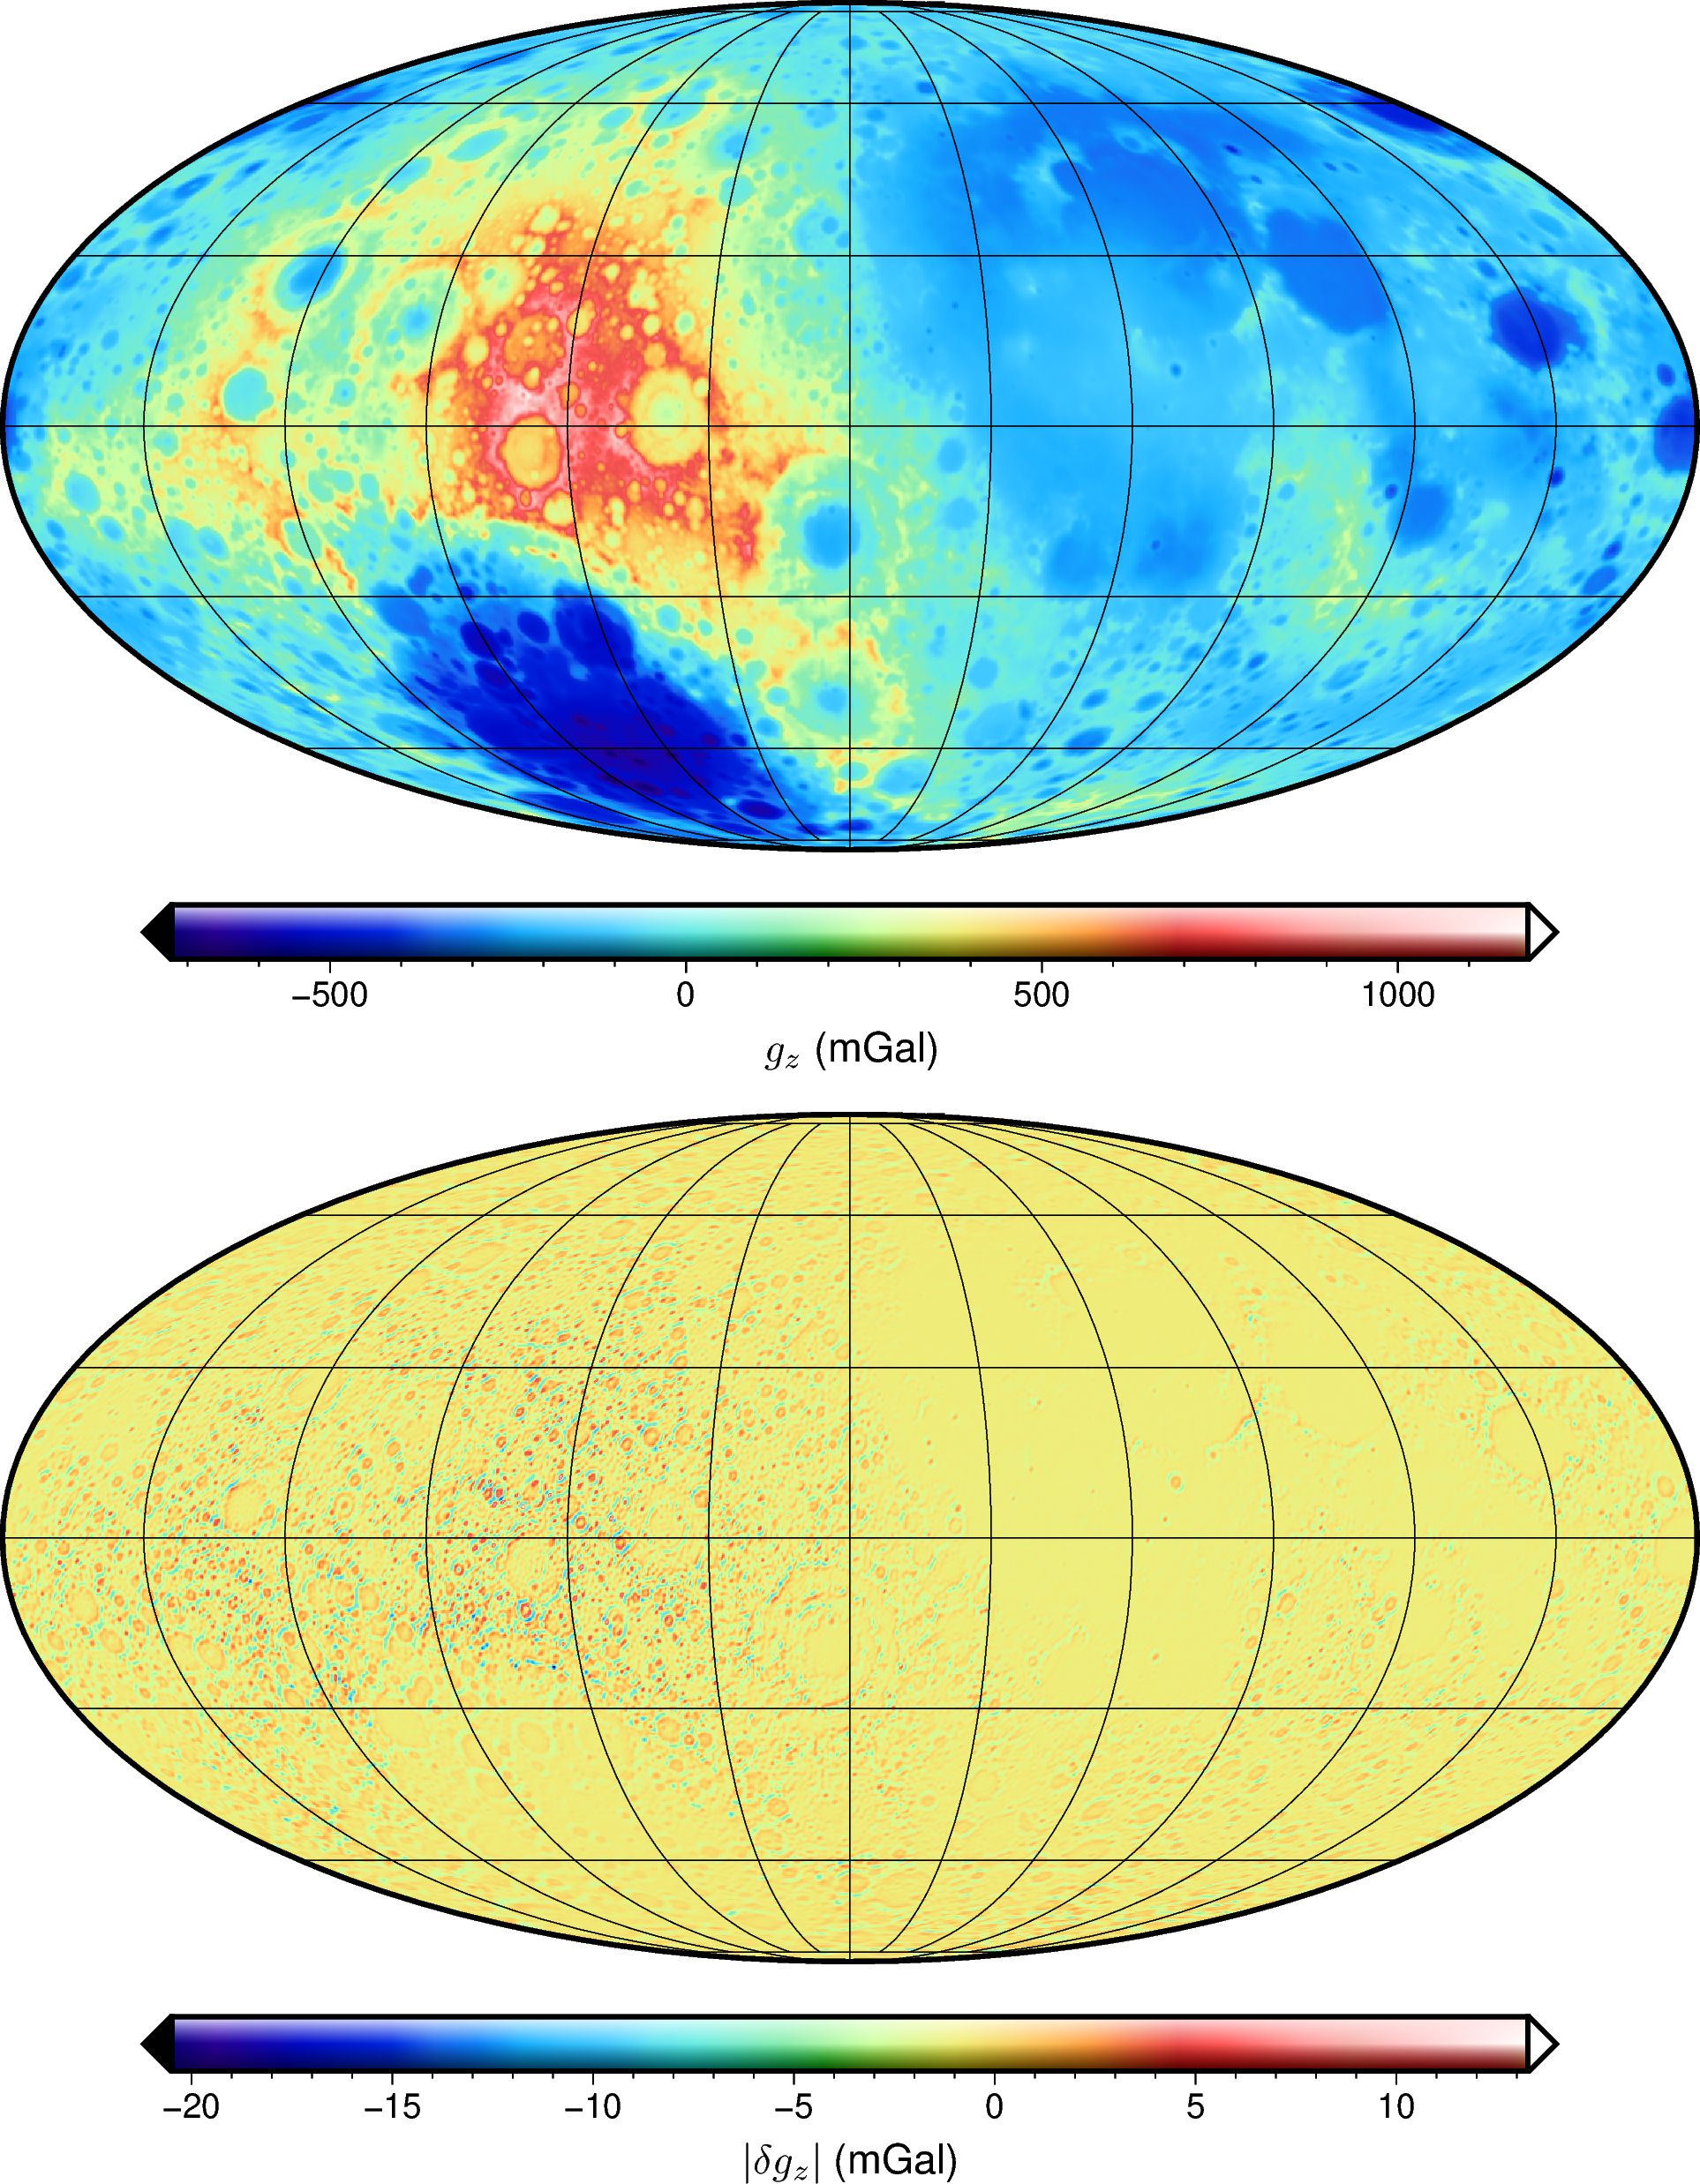

In [ ]:
# # ! Mapping: SH vs PH
grd_gd_PH = pysh.SHGrid.from_array(gd_PH)
grd_d_gd = pysh.SHGrid.from_array(d_gd)
fig = pygmt.Figure()
grd_gd_PH.plotgmt(fig=fig,
                  projection='mollweide',
                  central_longitude=-90.,
                  grid=[30, 30],
                  tick_interval=None,
                  cmap='haxby',
                  colorbar='bottom',
                  cb_triangles='both',
                  cb_label=r'@[ g_z @[ (mGal)',
                  cb_offset=15,
                  axes_labelsize=12,
                  shading=False)
grd_d_gd.plotgmt(fig=fig,
                 projection='mollweide',
                 central_longitude=-90.,
                 grid=[30, 30],
                 tick_interval=None,
                 cmap='haxby',
                 colorbar='bottom',
                 cb_triangles='both',
                 cb_label=r'@[ |\delta{g_z}| @[ (mGal)',
                 cb_offset=15,
                 axes_labelsize=12,
                 shading=False,
                 offset=[0, -4.2])
# fig.savefig('Moon_TopoGz_PH_vs_SH.png', dpi=400)
fig.show(width=800)

In [ ]:
# # ! Top-N largest gd errors (PH - SH)
n_largest = 30
abs_err = np.abs(d_gd).flatten()
idx_top = np.argpartition(abs_err, -n_largest)[-n_largest:]
err_vals = abs_err[idx_top]
sorted_order = np.argsort(-err_vals)
idx_top_sorted = idx_top[sorted_order]
lat_indices, lon_indices = np.unravel_index(idx_top_sorted, d_gd.shape)
lats_1d = grd_topo_moon.lats()
lons_1d = grd_topo_moon.lons()

print("=" * 104)
print(f"Top {n_largest} largest |gD| errors (PH - SH) in mGal")
print("=" * 104)
print(f"{'Rank':>4} | {'Lat (°)':>8} | {'Lon (°)':>8} | {'Topo (m)':>9} | "
      f"{'gD_SH':>10} | {'gD_PH':>10} | {'Error':>9} | {'|Error|':>9}")
print("-" * 104)
for rank in range(n_largest):
    i_lat = lat_indices[rank]
    i_lon = lon_indices[rank]
    lat = lats_1d[i_lat]
    lon = lons_1d[i_lon]
    topo_m = grd_topo_moon.data[i_lat, i_lon] * 1000.0
    gd_sh_val = gd_SH[i_lat, i_lon]
    gd_ph_val = gd_PH[i_lat, i_lon]
    error = d_gd[i_lat, i_lon]
    abs_error = np.abs(error)
    print(f"{rank+1:4d} | {lat:8.3f} | {lon:8.3f} | {topo_m:9.1f} | "
          f"{gd_sh_val:10.4f} | {gd_ph_val:10.4f} | {error:9.4f} | {abs_error:9.4f}")
print("=" * 104)

Top 30 largest |gD| errors (PH - SH) in mGal
Rank |  Lat (°) |  Lon (°) |  Topo (m) |      gD_SH |      gD_PH |     Error |   |Error|
--------------------------------------------------------------------------------------------------------
   1 |  -22.500 |  204.000 |    8551.1 |   693.1102 |   672.6280 |  -20.4821 |   20.4821
   2 |  -22.500 |  204.250 |    7828.7 |   625.1465 |   606.8462 |  -18.3003 |   18.3003
   3 |  -22.750 |  204.000 |    7843.9 |   640.1211 |   623.6422 |  -16.4790 |   16.4790
   4 |   -7.500 |  142.000 |    7378.5 |   670.6651 |   654.8978 |  -15.7673 |   15.7673
   5 |  -22.500 |  203.750 |    7876.4 |   650.5445 |   635.0364 |  -15.5081 |   15.5081
   6 |  -19.250 |  189.250 |    6149.1 |   450.9578 |   436.3604 |  -14.5975 |   14.5975
   7 |  -15.000 |  177.750 |    6982.5 |   610.2198 |   595.8525 |  -14.3673 |   14.3673
   8 |    6.750 |  195.500 |    8735.2 |   972.9469 |   958.6547 |  -14.2922 |   14.2922
   9 |  -22.250 |  195.750 |    5443.9 |   355.48

In [ ]:
# # ! End time
print("=" * 80)
print(f"End time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

End time: [2026-05-11 12:28:28]
